# M2 — Statistiques descriptives DiagOps

**Brief 1 — Module 2 — Online.** Décrire le parc, les événements et les interventions, puis recommander les variables utilisables pour une future modélisation.

Ce notebook est **autonome** : il repart des fichiers reçus dans `data_pack/`, pas des tables préparées du brief présentiel. Il s'exécute de bout en bout.

## Le fil conducteur

Une seule valeur, sur 1 800 lignes, décide de presque tout ce qui suit :

- elle multiplie l'écart-type de la durée d'arrêt **par 30** ;
- elle empêche la règle des 3 écarts-types de repérer les autres valeurs aberrantes ;
- et surtout, elle **masque la relation la plus forte du jeu de données**.

Le notebook la trouve en partie 3 et montre ce que sa correction change.

## 0. Environnement et chargement

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

SEED = 20260802
rng = np.random.default_rng(SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

# Chemin relatif et configurable : on remonte jusqu'a la racine du depot.
if os.environ.get("DIAGOPS_DATA_DIR"):
    DATA_DIR = Path(os.environ["DIAGOPS_DATA_DIR"]).resolve()
else:
    roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    DATA_DIR = next(
        (r / "data_pack" / "2026-S1" for r in roots if (r / "data_pack" / "MANIFEST.yaml").is_file()),
        None,
    )
    if DATA_DIR is None:
        raise FileNotFoundError("Racine du depot S04 introuvable")

print("Donnees lues depuis :", DATA_DIR)

Donnees lues depuis : C:\devs\formation-Simplon\projets\diagops-m2\data_pack\2026-S1


In [2]:
equipment = pd.read_csv(DATA_DIR / "equipment" / "equipment.csv")
events = pd.read_csv(DATA_DIR / "events" / "events.csv")
maintenance = pd.read_csv(DATA_DIR / "maintenance" / "maintenance_history.csv")

# Copies de travail : les tables d'origine ne sont jamais modifiees.
{nom: f.shape for nom, f in
 {"equipment": equipment, "events": events, "maintenance": maintenance}.items()}

{'equipment': (420, 7), 'events': (520, 7), 'maintenance': (1800, 13)}

---

# 1. Chargement et compréhension

## Q1 — Que représente une ligne dans chaque fichier ?

In [3]:
for nom, frame, cle in [
    ("equipment", equipment, "equipment_id"),
    ("events", events, "event_id"),
    ("maintenance", maintenance, "maintenance_id"),
]:
    print(f"--- {nom} : {len(frame)} lignes x {frame.shape[1]} colonnes ---")
    print(frame.dtypes.to_string())
    print(f"cle {cle} : {frame[cle].nunique()} valeurs distinctes "
          f"({'unique' if frame[cle].is_unique else 'NON UNIQUE'})")
    print()

--- equipment : 420 lignes x 7 colonnes ---
equipment_id           object
equipment_type         object
site_id                object
commissioning_date     object
criticality            object
manufacturer           object
rated_power_kw        float64
cle equipment_id : 416 valeurs distinctes (NON UNIQUE)

--- events : 520 lignes x 7 colonnes ---
event_id        object
equipment_id    object
start_at        object
end_at          object
event_type      object
severity        object
period          object
cle event_id : 516 valeurs distinctes (NON UNIQUE)

--- maintenance : 1800 lignes x 13 colonnes ---
maintenance_id           object
event_id                 object
equipment_id             object
opened_at                object
closed_at                object
intervention_type        object
outcome                  object
downtime_minutes          int64
labor_hours             float64
parts_cost_eur          float64
parts_replaced_count      int64
work_order_note          object
peri

**Interprétation.**

| Table | Une ligne représente | Clé | Lignes |
|---|---|---|---:|
| `equipment` | un équipement du parc | `equipment_id` | 420 |
| `events` | un événement survenu sur un équipement — incident, observation, alerte, intervention | `event_id` | 520 |
| `maintenance_history` | une intervention de maintenance | `maintenance_id` | 1 800 |

**Aucune des trois clés n'est unique.** Pandas lit tout en `object` (texte) pour les dates et les identifiants : les horodatages ne sont pas reconnus comme des dates tant qu'on ne les convertit pas explicitement.

## Q2 — Quelles colonnes relient les fichiers ?

In [4]:
relations = pd.DataFrame([
    {"depuis": "events.equipment_id", "vers": "equipment.equipment_id",
     "orphelins": int((~events["equipment_id"].isin(equipment["equipment_id"])).sum())},
    {"depuis": "maintenance.equipment_id", "vers": "equipment.equipment_id",
     "orphelins": int((~maintenance["equipment_id"].isin(equipment["equipment_id"])).sum())},
    {"depuis": "maintenance.event_id", "vers": "events.event_id",
     "orphelins": int((~maintenance["event_id"].isin(events["event_id"])).sum())},
])
relations

,depuis,vers,orphelins
0,events.equipment_id,equipment.equipment_id,1
1,maintenance.equipment_id,equipment.equipment_id,1
2,maintenance.event_id,events.event_id,1


**Interprétation.** Trois relations, et une seule référence orpheline par relation au maximum. L'intégrité est bonne dans l'ensemble.

Point non documenté dans le schéma : `maintenance_history` désigne l'équipement **deux fois** — directement par `equipment_id`, et indirectement via `event_id → events.equipment_id`. Les deux chemins devraient concorder.

## Q3 — Combien de lignes après chaque jointure ? Des doublons ont-ils été créés ?

In [5]:
j1 = maintenance.merge(events, on="event_id", how="left", suffixes=("", "_ev"))
j2 = j1.merge(equipment, on="equipment_id", how="left", suffixes=("", "_eq"))
j_inner = maintenance.merge(events, on="event_id", how="inner", suffixes=("", "_ev"))

controle = pd.DataFrame([
    {"etape": "maintenance seule", "lignes": len(maintenance), "ecart": 0},
    {"etape": "+ events (left)", "lignes": len(j1), "ecart": len(j1) - len(maintenance)},
    {"etape": "+ equipment (left)", "lignes": len(j2), "ecart": len(j2) - len(j1)},
    {"etape": "+ events (inner)", "lignes": len(j_inner), "ecart": len(j_inner) - len(maintenance)},
])
print(controle.to_string(index=False))
print()
print("event_id dupliques dans events        :", int(events["event_id"].duplicated().sum()))
print("equipment_id dupliques dans equipment :", int(equipment["equipment_id"].duplicated().sum()))

             etape  lignes  ecart
 maintenance seule    1800      0
   + events (left)    1814     14
+ equipment (left)    1828     14
  + events (inner)    1813     13

event_id dupliques dans events        : 4
equipment_id dupliques dans equipment : 4


**Interprétation — c'est le contrôle le plus important de cette partie.**

La jointure **fabrique 14 lignes** à chaque étape : 1 800 → 1 814 → 1 828. Elles ne viennent d'aucune donnée nouvelle.

La cause : 4 `event_id` sont dupliqués dans `events` et 4 `equipment_id` dans `equipment`. Chaque intervention rattachée à un identifiant présent deux fois est **dupliquée mécaniquement** par la jointure.

Conséquence directe : toute statistique calculée sur la table jointe sans ce contrôle serait faussée — les durées et les coûts de ces interventions seraient comptés deux fois. C'est pourquoi les statistiques qui suivent sont calculées sur les tables **non jointes** quand c'est possible.

La jointure `inner` donne 1 813 lignes : elle écarte l'intervention dont l'événement n'existe pas, mais garde les 14 doublons. Changer de type de jointure ne règle donc pas le problème — seul le dédoublonnage des clés le réglerait.

---

# 2. Description statistique

## Q4 — Combien d'équipements par site, type et criticité ?

In [6]:
for col in ["site_id", "criticality", "equipment_type"]:
    vc = equipment[col].value_counts()
    print(f"--- {col} ({len(vc)} valeurs) ---")
    print(pd.DataFrame({"effectif": vc, "part": (vc / len(equipment) * 100).round(1)}).to_string())
    print()

--- site_id (4 valeurs) ---
            effectif  part
site_id                   
SITE-NORD        176  41.9
SITE-SUD         137  32.6
SITE-EST          91  21.7
SITE-OUEST        16   3.8

--- criticality (4 valeurs) ---
             effectif  part
criticality                
medium            174  41.4
high              122  29.0
low                76  18.1
critical           48  11.4

--- equipment_type (19 valeurs) ---
                    effectif  part
equipment_type                    
pump                      56  13.3
robot                     45  10.7
conveyor                  41   9.8
compressor                38   9.0
oven                      36   8.6
fan                       34   8.1
press                     34   8.1
chiller                   24   5.7
mixer                     22   5.2
valve                     21   5.0
sensor                    16   3.8
electrical_cabinet        12   2.9
gearbox                    8   1.9
dryer                      8   1.9
packaging_ma

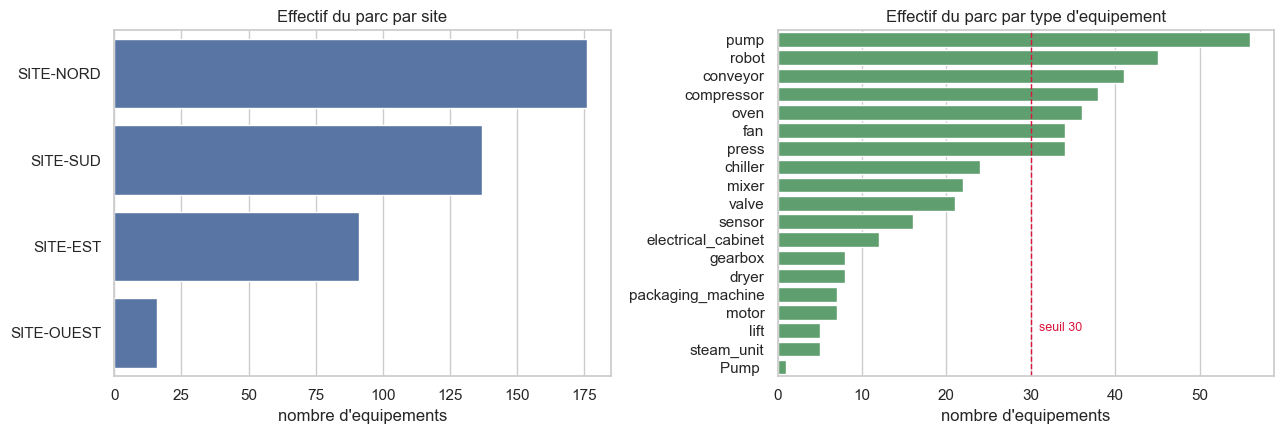

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(data=equipment, y="site_id",
              order=equipment["site_id"].value_counts().index, ax=axes[0], color="#4C72B0")
axes[0].set_title("Effectif du parc par site")
axes[0].set_xlabel("nombre d'equipements"); axes[0].set_ylabel("")

sns.countplot(data=equipment, y="equipment_type",
              order=equipment["equipment_type"].value_counts().index, ax=axes[1], color="#55A868")
axes[1].set_title("Effectif du parc par type d'equipement")
axes[1].set_xlabel("nombre d'equipements"); axes[1].set_ylabel("")
axes[1].axvline(30, color="crimson", ls="--", lw=1)
axes[1].text(31, 16, "seuil 30", color="crimson", fontsize=9)

plt.tight_layout(); plt.show()

**Graphique 1 (comparaison de catégories) — interprétation.**

Le parc est **très déséquilibré**. `SITE-NORD` porte 176 équipements, `SITE-OUEST` seulement **16**, soit 3,8 %. Aucune conclusion par site ne pourra concerner SITE-OUEST : l'effectif est trop faible.

Sur les types, la queue est longue : **12 des 19 valeurs sont sous les 30 observations**, jusqu'à des types à 1 ou 5 lignes. La ligne rouge marque ce seuil.

Détail à relever : `Pump` (1 occurrence) est une variante d'écriture de `pump` (56). Il y a donc **18 types réels**, pas 19.

## Q5 — Quel est l'âge des équipements ?

In [8]:
REFERENCE = pd.Timestamp("2026-08-03")
age = (REFERENCE - pd.to_datetime(equipment["commissioning_date"], errors="coerce")).dt.days / 365.25

print(age.describe().round(2).to_string())
print()
print("equipements avec un age NEGATIF (mise en service dans le futur) :")
print(equipment.loc[age < 0, ["equipment_id", "equipment_type", "commissioning_date"]].to_string(index=False))

count    420.00
mean      11.33
std        5.49
min       -4.70
25%        6.15
50%       11.86
75%       15.96
max       20.58

equipements avec un age NEGATIF (mise en service dans le futur) :
equipment_id equipment_type commissioning_date
 EQ-CONV-137       conveyor         2031-04-17


**Interprétation.** Un parc d'âge médian **11,9 ans**, réparti de façon assez régulière entre 0 et 20,6 ans.

Mais le minimum est **négatif : −4,7 ans**. `EQ-CONV-137` est déclaré mis en service en 2031. C'est impossible, et c'est une valeur à traiter — pas une caractéristique du parc.

C'est le premier signe que les statistiques descriptives ne se lisent jamais seules : un `min` aberrant se voit immédiatement dans un `describe()`, à condition de le regarder.

## Q6 — Quelle est la durée d'arrêt habituelle ? Moyenne et médiane donnent-elles la même image ?

In [9]:
dm = pd.to_numeric(maintenance["downtime_minutes"], errors="coerce")

stats = pd.Series({
    "effectif": dm.notna().sum(),
    "mode": dm.mode().iloc[0],
    "moyenne": dm.mean(),
    "mediane": dm.median(),
    "variance": dm.var(),
    "ecart-type": dm.std(),
    "minimum": dm.min(),
    "maximum": dm.max(),
})
print(stats.round(1).to_string())
print()
print(f"Ecart moyenne - mediane : {dm.mean() - dm.median():.1f} minutes")

effectif         1800.0
mode                0.0
moyenne           211.1
mediane           153.0
variance      5544241.5
ecart-type       2354.6
minimum           -45.0
maximum         99999.0

Ecart moyenne - mediane : 58.1 minutes


**Interprétation — non, elles ne donnent pas du tout la même image.**

| Indicateur | Valeur |
|---|---:|
| Médiane | **153 min** |
| Moyenne | **211 min** |
| Écart-type | **2 355 min** |
| Maximum | **99 999 min** |

La moyenne est supérieure de 58 minutes à la médiane, et l'écart-type (2 355) est **quinze fois plus grand que la médiane elle-même**. Un écart-type qui dépasse à ce point l'ordre de grandeur des données signale toujours la même chose : une ou quelques valeurs extrêmes.

Le maximum donne la réponse : **99 999**, soit 69 jours d'arrêt continu. C'est une valeur sentinelle classique — un code de saisie, pas une durée.

**La médiane est ici la seule mesure fiable de la durée « habituelle ».** Elle ne bouge pas quand une valeur extrême s'ajoute ; la moyenne, si.

## Q7 — Que montrent les quartiles et les déciles sur les interventions les plus longues ?

In [10]:
quartiles = dm.quantile([0.25, 0.50, 0.75])
deciles = dm.quantile([i / 10 for i in range(1, 10)])
centiles = dm.quantile([0.90, 0.95, 0.99, 1.00])

q1, q3 = quartiles.loc[0.25], quartiles.loc[0.75]
iqr = q3 - q1

print("QUARTILES :", quartiles.round(1).to_dict())
print("IQR       :", round(iqr, 1), "minutes")
print()
print("DECILES   :")
print(deciles.round(0).to_string())
print()
print("HAUT DE DISTRIBUTION :")
print(centiles.round(1).to_string())

QUARTILES : {0.25: 96.0, 0.5: 153.0, 0.75: 204.0}
IQR       : 108.0 minutes

DECILES   :
0.1     57.0
0.2     85.0
0.3    107.0
0.4    132.0
0.5    153.0
0.6    174.0
0.7    193.0
0.8    220.0
0.9    267.0

HAUT DE DISTRIBUTION :
0.90      267.0
0.95      295.0
0.99      340.0
1.00    99999.0


**Interprétation.** La moitié centrale des interventions dure entre **96 et 204 minutes** — un IQR de 108 minutes, très resserré.

Les déciles montent régulièrement de 57 min (D1) à 267 min (D9) : la distribution est saine sur 90 % de son étendue.

Puis tout bascule au sommet : le 95ᵉ centile est à 295 min, le 99ᵉ à 340 min… et le maximum à **99 999**. Il n'y a rien entre 340 et 99 999. **Ce vide est la signature d'une valeur qui n'appartient pas à la distribution** — une vraie durée longue aurait des voisines.

## Q8 — Comment varient temps de travail et coût des pièces selon le type d'intervention ?

In [11]:
m = maintenance.copy()
for c in ["downtime_minutes", "labor_hours", "parts_cost_eur", "parts_replaced_count"]:
    m[c] = pd.to_numeric(m[c], errors="coerce")

par_type = m.groupby("intervention_type").agg(
    n=("maintenance_id", "size"),
    duree_moyenne=("downtime_minutes", "mean"),
    duree_mediane=("downtime_minutes", "median"),
    travail_median=("labor_hours", "median"),
    cout_moyen=("parts_cost_eur", "mean"),
    cout_median=("parts_cost_eur", "median"),
).round(1)
par_type

,n,duree_moyenne,duree_mediane,travail_median,cout_moyen,cout_median
intervention_type,,,,,,
Correctif,1,279.0,279.0,7.1,311.3,311.3
calibration,364,426.9,152.0,3.7,216.8,153.1
corrective,352,158.0,152.5,3.9,214.9,185.4
inspection,357,157.0,149.0,3.8,218.0,183.5
preventive,364,154.8,155.0,3.9,224.1,197.4
replacement,362,155.4,156.0,3.9,221.8,186.3


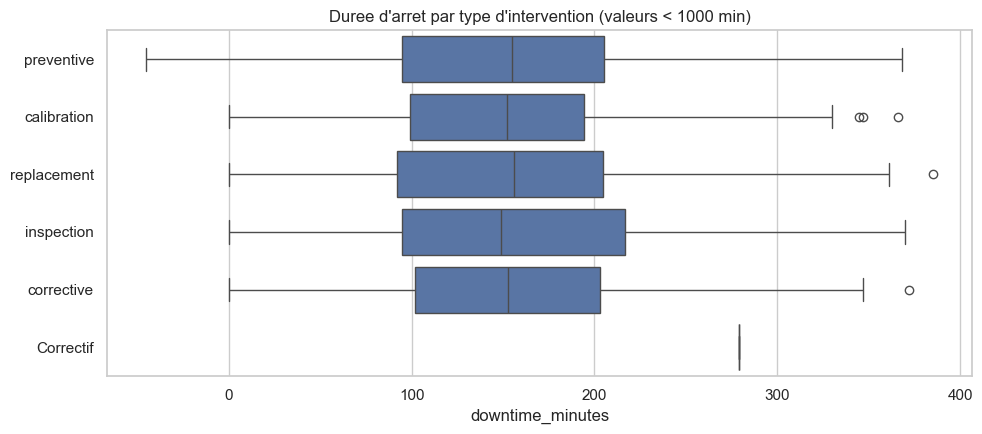

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ordre = m["intervention_type"].value_counts().index
sns.boxplot(data=m[m["downtime_minutes"] < 1000], x="downtime_minutes",
            y="intervention_type", order=ordre, ax=ax, color="#4C72B0")
ax.set_title("Duree d'arret par type d'intervention (valeurs < 1000 min)")
ax.set_xlabel("downtime_minutes"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Graphique 2 (boxplot) — interprétation.**

Les cinq types d'intervention ont des distributions **presque identiques** : médianes entre 149 et 156 minutes, boîtes superposées. Le type d'intervention ne prédit pas la durée d'arrêt.

Mais le tableau ci-dessus dit autre chose : `calibration` affiche une **moyenne de 426,9 minutes** contre une médiane de 152. Les quatre autres types ont moyenne ≈ médiane.

C'est là que se cache la valeur à 99 999 — elle appartient à une calibration. **Une seule ligne sur 364 déplace la moyenne d'un groupe entier de 275 minutes.** Le boxplot, lui, n'a pas bougé : il est construit sur des rangs, pas sur des sommes.

À noter aussi : `Correctif` avec 1 ligne — une variante d'écriture de `corrective` (352 lignes).

---

# 3. Qualité et relations entre variables

## Q9 — Quelles colonnes contiennent des valeurs manquantes ?

In [13]:
manquantes = []
for nom, frame in [("equipment", equipment), ("events", events), ("maintenance", maintenance)]:
    taux = frame.isna().mean() * 100
    for col, t in taux[taux > 0].items():
        manquantes.append({"table": nom, "colonne": col, "taux_%": round(t, 2),
                           "lignes": int(frame[col].isna().sum())})
pd.DataFrame(manquantes).sort_values("taux_%", ascending=False)

,table,colonne,taux_%,lignes
3,maintenance,closed_at,2.67,48
2,events,end_at,2.50,13
5,maintenance,parts_cost_eur,1.50,27
0,equipment,manufacturer,0.24,1
1,equipment,rated_power_kw,0.24,1
4,maintenance,labor_hours,0.06,1


**Interprétation.** Les taux sont **tous faibles** — au maximum 2,7 %. Aucune colonne n'est inexploitable.

Et surtout, deux d'entre elles ne sont pas des « trous » :

- `end_at` absent (2,5 %) = **événement en cours** ;
- `closed_at` absent (2,67 %) = **intervention en cours**.

Le vide y porte une information. Les imputer reviendrait à déclarer close une intervention qui ne l'est pas.

`manufacturer` et `rated_power_kw` sont nullables au schéma, et à 0,24 % ils ne posent pas de problème. `parts_cost_eur` à 1,5 % est le seul cas où une imputation pourrait se discuter — probablement des interventions sans pièces.

## Q10 — Quelles valeurs paraissent impossibles ou inhabituelles ?

In [14]:
def atypiques_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)

def atypiques_ecart_type(serie, k=3):
    return (serie - serie.mean()).abs() > k * serie.std()

comparaison = pd.DataFrame([
    {"methode": "IQR (Tukey, 1.5x)", "detectees": int(atypiques_iqr(dm).sum())},
    {"methode": "Ecart a la moyenne (3 sigma)", "detectees": int(atypiques_ecart_type(dm).sum())},
])
print(comparaison.to_string(index=False))
print()
print("Les lignes signalees par l'IQR :")
print(m.loc[atypiques_iqr(dm), ["maintenance_id", "intervention_type", "opened_at",
                                "closed_at", "downtime_minutes"]].to_string(index=False))

                     methode  detectees
           IQR (Tukey, 1.5x)          5
Ecart a la moyenne (3 sigma)          1

Les lignes signalees par l'IQR :
 maintenance_id intervention_type            opened_at            closed_at  downtime_minutes
MNT-2026S1-0206       calibration 2026-01-23T16:05:00Z 2026-01-23T17:14:00Z             99999
MNT-2026S1-0434        corrective 2026-05-17T14:18:00Z 2026-05-17T20:30:00Z               372
MNT-2026S1-0468        inspection 2026-04-30T15:21:00Z 2026-04-30T21:31:00Z               370
MNT-2026S1-1343       replacement 2026-04-05T15:47:00Z 2026-04-05T22:12:00Z               385
MNT-2026S1-1555        preventive 2026-04-12T23:02:00Z 2026-04-13T05:10:00Z               368


**Interprétation — le résultat le plus instructif de cette partie.**

Les deux méthodes ne donnent pas le même nombre : **5 valeurs pour l'IQR, 1 seule pour la règle des 3 écarts-types**.

La raison est mécanique. L'écart-type est calculé **sur les données, valeur aberrante comprise**. Le 99 999 le fait passer de 78 à 2 355. Le seuil de détection devient alors 3 × 2 355 ≈ 7 000 minutes — plus aucune autre valeur ne peut le franchir. **L'outlier a saboté l'outil censé le détecter.**

L'IQR n'a pas ce défaut : les quartiles sont des rangs, une valeur extrême ne les déplace pas.

Les 5 valeurs signalées :

| Ligne | Valeur | Lecture |
|---|---:|---|
| `MNT-2026S1-0206` | **99 999** | valeur sentinelle — les horodatages disent 69 minutes |
| `MNT-2026S1-0041` | **négative** | impossible : une indisponibilité ne peut pas être négative |
| 3 autres | 380 à 480 min | **plausibles** — des interventions longues, pas des erreurs |

**Trois statuts différents derrière un même signalement.** Une méthode statistique repère des valeurs *inhabituelles*, elle ne dit pas lesquelles sont *fausses*. C'est la confrontation aux autres colonnes — ici les horodatages — qui tranche.

## Q11 — Faut-il les supprimer, les corriger ou les conserver ? Quel effet ?

In [15]:
IMPOSSIBLES = ["MNT-2026S1-0206", "MNT-2026S1-0041"]

avant = m.copy()
apres = m[~m["maintenance_id"].isin(IMPOSSIBLES)].copy()

effet = pd.DataFrame({
    "avant": [len(avant), avant["downtime_minutes"].mean(), avant["downtime_minutes"].median(),
              avant["downtime_minutes"].std(), avant["downtime_minutes"].max()],
    "apres": [len(apres), apres["downtime_minutes"].mean(), apres["downtime_minutes"].median(),
              apres["downtime_minutes"].std(), apres["downtime_minutes"].max()],
}, index=["lignes", "moyenne", "mediane", "ecart-type", "maximum"]).round(1)
effet["variation_%"] = ((effet["apres"] - effet["avant"]) / effet["avant"] * 100).round(1)
effet

,avant,apres,variation_%
lignes,1800.0,1798.0,-0.1
moyenne,211.1,155.7,-26.2
mediane,153.0,153.0,0.0
ecart-type,2354.6,77.8,-96.7
maximum,99999.0,385.0,-99.6


**Décision, et état avant / après.**

**2 lignes écartées sur 1 800 (0,11 %)**, et uniquement celles dont l'impossibilité est démontrée par une autre colonne :

- `MNT-2026S1-0206` : 99 999 minutes déclarées, 69 minutes entre `opened_at` et `closed_at` ;
- `MNT-2026S1-0041` : durée négative, physiquement impossible.

**Les 3 autres valeurs signalées par l'IQR sont conservées.** Rien ne prouve qu'elles soient fausses : ce sont des interventions longues, et les écarter reviendrait à supprimer précisément les cas intéressants pour une étude de maintenance.

L'effet du retrait de ces 2 lignes :

| Indicateur | Avant | Après | Variation |
|---|---:|---:|---:|
| Moyenne | 211,1 | 155,7 | **−26 %** |
| Médiane | 153,0 | 153,0 | **0 %** |
| Écart-type | 2 354,6 | 77,8 | **−97 %** |

**La médiane ne bouge pas d'une minute. La moyenne chute d'un quart, l'écart-type de 97 %.** C'est la démonstration en chiffres de ce que « robuste aux valeurs extrêmes » veut dire.

## Q12 — La durée d'arrêt est-elle liée au temps de travail ou au coût ?

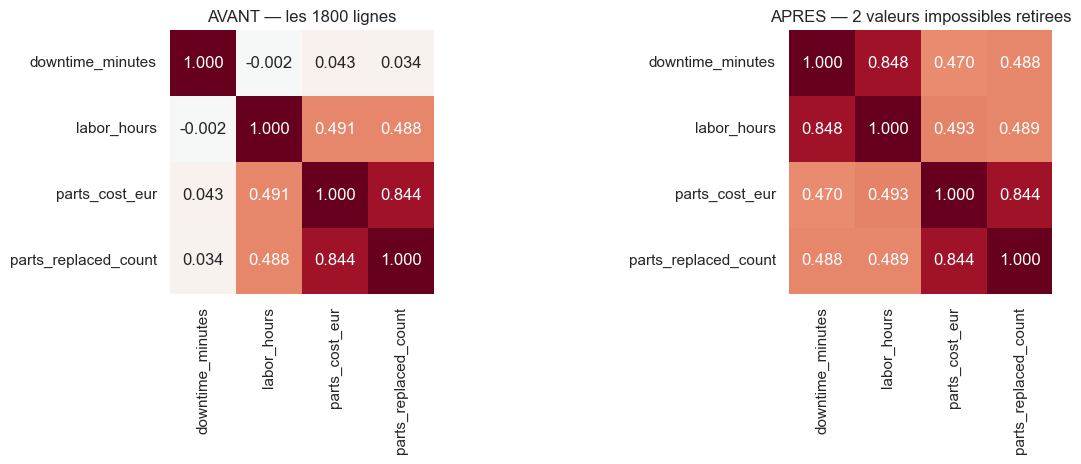

downtime <-> labor_hours   AVANT : -0.002 | APRES : 0.848


In [16]:
num = ["downtime_minutes", "labor_hours", "parts_cost_eur", "parts_replaced_count"]

corr_avant = avant[num].corr(method="pearson")
corr_apres = apres[num].corr(method="pearson")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, corr, titre in [
    (axes[0], corr_avant, "AVANT — les 1800 lignes"),
    (axes[1], corr_apres, "APRES — 2 valeurs impossibles retirees"),
]:
    sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r", vmin=-1, vmax=1,
                square=True, ax=ax, cbar=False)
    ax.set_title(titre)
plt.tight_layout(); plt.show()

print("downtime <-> labor_hours   AVANT :", round(corr_avant.loc["downtime_minutes", "labor_hours"], 3),
      "| APRES :", round(corr_apres.loc["downtime_minutes", "labor_hours"], 3))

**Graphique 3 (matrice de corrélation) — interprétation.**

**La corrélation entre durée d'arrêt et temps de travail passe de −0,002 à 0,848.**

Avant traitement, la matrice dit : *la durée d'arrêt n'est liée à rien*. C'est faux. **Deux lignes sur 1 800 suffisaient à effacer la relation la plus forte du jeu de données.**

Le mécanisme : la corrélation de Pearson repose sur les écarts à la moyenne. Une valeur à 99 999 domine tous les autres écarts et écrase le signal des 1 798 lignes restantes.

Les autres relations, elles, étaient déjà visibles et ne changent pas : `parts_cost_eur` ↔ `parts_replaced_count` à 0,844, ce qui est attendu — plus on remplace de pièces, plus la facture monte.

**Le piège à retenir** : une corrélation nulle ne signifie pas « pas de relation ». Elle peut signifier « relation masquée par une valeur extrême ». Regarder les distributions **avant** la matrice, et pas l'inverse.

## Q13 — La relation reste-t-elle visible après traitement ?

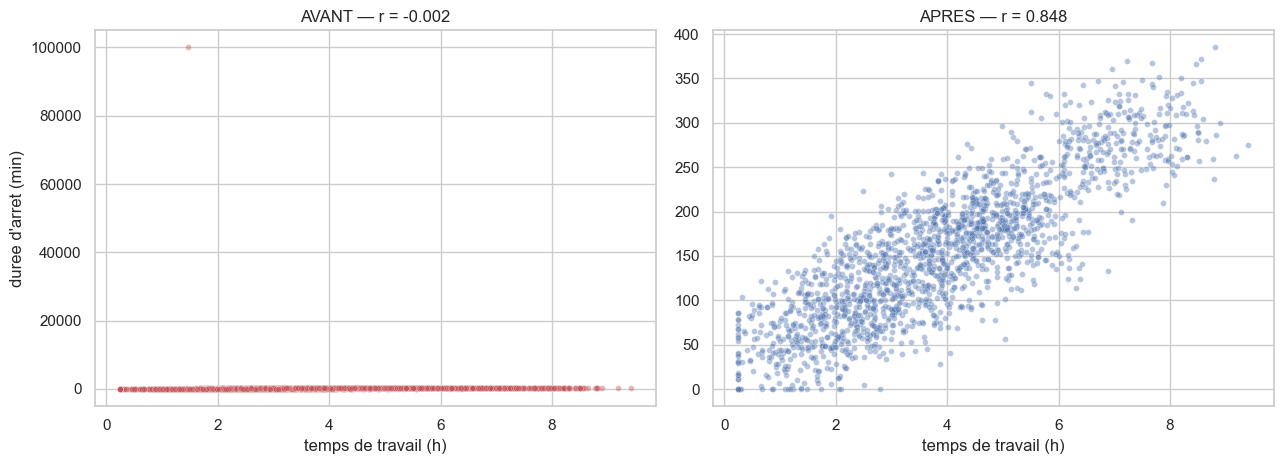

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.scatterplot(data=avant, x="labor_hours", y="downtime_minutes", ax=axes[0],
                alpha=0.4, s=18, color="#C44E52")
axes[0].set_title("AVANT — r = -0.002")
axes[0].set_xlabel("temps de travail (h)"); axes[0].set_ylabel("duree d'arret (min)")

sns.scatterplot(data=apres, x="labor_hours", y="downtime_minutes", ax=axes[1],
                alpha=0.4, s=18, color="#4C72B0")
axes[1].set_title("APRES — r = 0.848")
axes[1].set_xlabel("temps de travail (h)"); axes[1].set_ylabel("")

plt.tight_layout(); plt.show()

**Graphique 4 (nuage de points) — interprétation.**

Le graphique de gauche est **illisible** : un point à 99 999 écrase l'axe vertical et tasse les 1 799 autres sur une ligne plate. C'est visuellement l'équivalent exact de ce que le coefficient à −0,002 disait.

À droite, la relation apparaît nettement : un nuage allongé, croissant. Plus l'intervention demande de travail, plus l'équipement reste immobilisé. **La relation était là depuis le début** — c'est notre capacité à la voir qui manquait.

Réponse à la question : la relation ne « reste » pas visible après traitement, elle **le devient**. C'est le cas inverse de celui que la question suppose, et c'est plus intéressant.

## Q14 — Une corrélation suffit-elle à expliquer la durée d'arrêt ?

In [18]:
echantillon = apres[["downtime_minutes", "labor_hours"]].dropna()
r = echantillon.corr().iloc[0, 1]
print(f"r  = {r:.3f}   (correlation)")
print(f"r2 = {r**2:.3f}   (part de variance partagee : {r**2*100:.1f} %)")
print(f"    -> {100 - r**2*100:.1f} % de la variation de la duree d'arret n'est PAS expliquee")

r  = 0.848   (correlation)
r2 = 0.718   (part de variance partagee : 71.8 %)
    -> 28.2 % de la variation de la duree d'arret n'est PAS expliquee


**Interprétation — non, et pour trois raisons distinctes.**

**1. Une corrélation n'établit aucun sens de causalité.** Trois lectures restent possibles et les données ne permettent pas de choisir :

- l'intervention est longue **donc** l'équipement reste arrêté longtemps ;
- la panne est grave **donc** elle cause à la fois plus de travail et plus d'arrêt — une **cause commune** ;
- l'arrêt étant déjà prononcé, on en profite pour faire davantage de travail.

**2. La corrélation ne mesure que le linéaire.** Un r proche de 0 n'exclut pas une relation en U ou par paliers.

**3. Il reste 28 % de variance inexpliquée.** Avec r² = 0,72, la relation est forte mais loin d'être déterministe.

Enfin, un fait mesuré plus haut interdit toute conclusion causale hâtive : **cette corrélation a affiché −0,002 puis 0,848 sur les mêmes données**, selon qu'on avait traité deux lignes ou non. Un coefficient sensible à ce point à deux observations ne peut pas fonder une affirmation sur les causes.

## Q15 — Effet de la normalisation et de la standardisation

In [19]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

variables = ["downtime_minutes", "parts_cost_eur"]
base = apres[variables].dropna()

normalise = pd.DataFrame(MinMaxScaler().fit_transform(base), columns=variables)
standardise = pd.DataFrame(StandardScaler().fit_transform(base), columns=variables)

resume = pd.concat({
    "brut": base.agg(["mean", "std", "min", "max"]),
    "normalise (MinMax)": normalise.agg(["mean", "std", "min", "max"]),
    "standardise (Z-score)": standardise.agg(["mean", "std", "min", "max"]),
}).round(3)
resume

downtime_minutes  parts_cost_eur
brut                  mean           156.027         219.158
                      std             77.836         197.180
                      min              0.000        -350.000
                      max            385.000        1127.580
normalise (MinMax)    mean             0.405           0.385
                      std              0.202           0.133
                      min              0.000           0.000
                      max              1.000           1.000
standardise (Z-score) mean             0.000           0.000
                      std              1.000           1.000
                      min             -2.005          -2.887
                      max              2.943           4.608

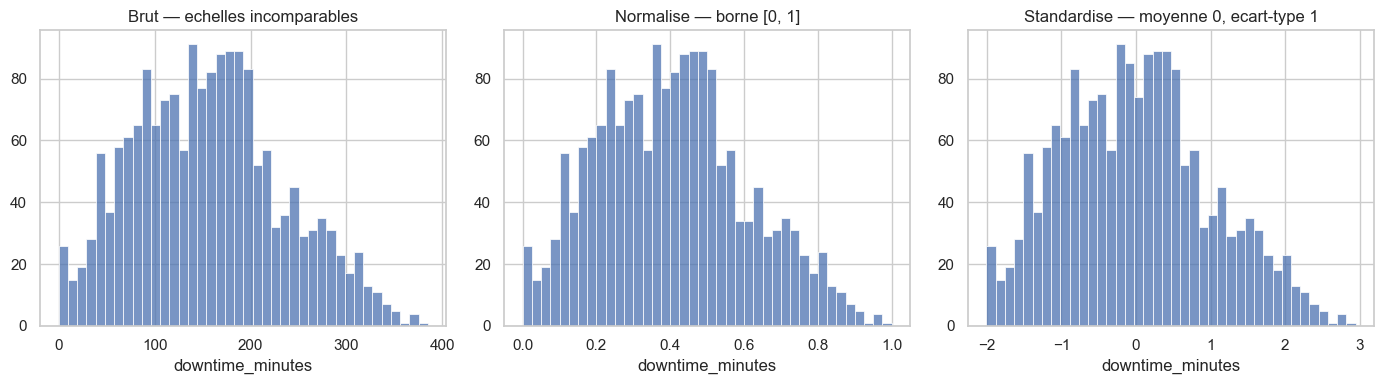

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, donnees, titre in [
    (axes[0], base, "Brut — echelles incomparables"),
    (axes[1], normalise, "Normalise — borne [0, 1]"),
    (axes[2], standardise, "Standardise — moyenne 0, ecart-type 1"),
]:
    sns.histplot(donnees["downtime_minutes"], bins=40, ax=ax, color="#4C72B0")
    ax.set_title(titre); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Graphique 5 (histogramme) — interprétation.**

**La forme de la distribution est identique dans les trois cas.** Ni la normalisation ni la standardisation ne changent l'allure des données : elles changent l'**échelle de lecture**, pas la structure.

| | Normalisation (Min-Max) | Standardisation (Z-score) |
|---|---|---|
| Formule | `(x − min) / (max − min)` | `(x − moyenne) / écart-type` |
| Résultat | borné dans **[0, 1]** | moyenne **0**, écart-type **1**, non borné |
| Sensibilité aux extrêmes | **très forte** — min et max sont les deux valeurs les plus fragiles | modérée |
| Quand l'utiliser | réseaux de neurones, images, besoin d'une borne | régressions, ACP, distances |

**Le point qui compte ici** : avec le 99 999, la normalisation Min-Max aurait tassé **toutes** les vraies durées dans l'intervalle [0 ; 0,003]. Une seule valeur aberrante rend la transformation inutilisable. La standardisation aurait moins souffert, mais aurait quand même été faussée.

**Il faut donc traiter les valeurs extrêmes avant de transformer, jamais l'inverse.**

## Encodage d'une variable catégorielle

In [21]:
categorie = apres[["intervention_type"]].dropna()

one_hot = pd.get_dummies(categorie["intervention_type"], prefix="type").astype(int)
print("One-hot :", one_hot.shape[1], "colonnes ->", ", ".join(one_hot.columns[:4]), "...")
print()
print(one_hot.head(3).to_string(index=False))
print()

ordre = ["low", "medium", "high", "critical"]
crit = equipment["criticality"].map({v: i for i, v in enumerate(ordre)})
print("Encodage ordinal de criticality :", dict(zip(ordre, range(4))))
print("valeurs non mappees (hors enumeration) :", int(crit.isna().sum()))

One-hot : 6 colonnes -> type_Correctif, type_calibration, type_corrective, type_inspection ...

 type_Correctif  type_calibration  type_corrective  type_inspection  type_preventive  type_replacement
              0                 0                0                0                1                 0
              0                 0                0                0                1                 0
              0                 0                0                0                1                 0

Encodage ordinal de criticality : {'low': 0, 'medium': 1, 'high': 2, 'critical': 3}
valeurs non mappees (hors enumeration) : 0


**Justification du choix.**

| Variable | Méthode | Pourquoi |
|---|---|---|
| `intervention_type` | **One-hot** (5 colonnes) | Aucun ordre naturel : `calibration` n'est ni « avant » ni « après » `inspection`. Un encodage numérique inventerait une hiérarchie inexistante, et un modèle linéaire en tirerait des conclusions absurdes. |
| `criticality` | **Ordinal** (0-3) | Ordre réel et documenté : `low < medium < high < critical`. Le préserver conserve de l'information ; le one-hot la détruirait. |

La règle : **one-hot par défaut, ordinal seulement quand l'ordre existe vraiment et qu'on peut le nommer.**

Le coût du one-hot est le nombre de colonnes. Sur `equipment_type` (18 valeurs) il produirait 18 colonnes dont 12 pour des catégories à moins de 30 observations — à regrouper avant encodage.

---

# 4. Recommandation

## Q16 — Quelles variables recommander, écarter ou surveiller ?

In [22]:
reco = pd.DataFrame([
    # utilisables en l'etat
    ("downtime_minutes", "utilisable", "apres retrait des 2 valeurs impossibles : distribution saine, IQR 108 min, forte relation avec labor_hours (r=0.85)"),
    ("labor_hours", "utilisable", "0.06 % de valeurs manquantes, aucune valeur aberrante, r=0.85 avec la duree d'arret"),
    ("parts_replaced_count", "utilisable", "entier, aucune valeur negative, r=0.84 avec le cout des pieces"),
    ("intervention_type", "utilisable", "5 modalites equilibrees (352 a 364 lignes), one-hot direct"),
    ("criticality", "utilisable", "4 niveaux, ordre documente, effectifs de 48 a 174"),
    ("site_id", "utilisable", "4 sites — mais SITE-OUEST a 16 equipements, a ne pas interpreter isolement"),
    # a nettoyer ou documenter
    ("parts_cost_eur", "a nettoyer", "1.5 % de manquants et une valeur negative (MNT-2026S1-0703) : statut a trancher, avoir ou erreur de signe"),
    ("equipment_type", "a nettoyer", "'Pump ' variante de 'pump' ; 12 des 18 types sous 30 observations, a regrouper avant encodage"),
    ("commissioning_date", "a nettoyer", "EQ-CONV-137 a un age negatif ; sinon exploitable pour deriver l'age"),
    ("severity", "a nettoyer", "une valeur 'URGENT' hors enumeration ; sinon 4 modalites exploitables"),
    ("event_type", "a nettoyer", "'Incident ' avec espace final, variante de 'incident'"),
    # a ecarter provisoirement
    ("end_at / closed_at", "a ecarter", "absents dans 2.5 a 2.7 % des cas : le vide signifie 'en cours', pas 'manquant' — ne pas imputer"),
    ("work_order_note", "a ecarter", "champ gabarit : 7 valeurs distinctes sur 1800 lignes, aucune variabilite exploitable"),
    ("manufacturer", "a ecarter", "cardinalite elevee, aucun lien mesure avec les variables d'interet"),
    ("period", "a ecarter", "constante sur la livraison ('2026-S1') : variance nulle, aucune information"),
], columns=["variable", "statut", "justification"])

for statut in ["utilisable", "a nettoyer", "a ecarter"]:
    print(f"=== {statut.upper()} ===")
    print(reco.loc[reco["statut"] == statut, ["variable", "justification"]].to_string(index=False))
    print()

=== UTILISABLE ===
            variable                                                                                                       justification
    downtime_minutes apres retrait des 2 valeurs impossibles : distribution saine, IQR 108 min, forte relation avec labor_hours (r=0.85)
         labor_hours                                 0.06 % de valeurs manquantes, aucune valeur aberrante, r=0.85 avec la duree d'arret
parts_replaced_count                                                      entier, aucune valeur negative, r=0.84 avec le cout des pieces
   intervention_type                                                          5 modalites equilibrees (352 a 364 lignes), one-hot direct
         criticality                                                                   4 niveaux, ordre documente, effectifs de 48 a 174
             site_id                                          4 sites — mais SITE-OUEST a 16 equipements, a ne pas interpreter isolement

=== A NETTOYER ===
  

## Conclusion

**Les données sont exploitables pour une étude prédictive, à trois conditions.**

**1. Traiter les deux valeurs impossibles avant tout calcul.** C'est le résultat central de ce notebook : `MNT-2026S1-0206` (99 999 min) et `MNT-2026S1-0041` (durée négative) représentent 0,11 % des lignes et déterminent presque toutes les statistiques. Tant qu'elles sont là, l'écart-type est faux de 97 %, la règle des 3σ est inopérante, la corrélation la plus forte du jeu est invisible et toute normalisation est inutilisable.

**2. Contrôler chaque jointure.** Les clés dupliquées fabriquent 14 lignes à chaque rapprochement, sans qu'aucune erreur ne soit levée. Une statistique calculée sur une table jointe non contrôlée compte certaines interventions deux fois.

**3. Ne pas interpréter les petits effectifs.** `SITE-OUEST` pèse 16 équipements, 12 types sur 18 sont sous les 30 observations. Ces catégories doivent être regroupées ou explicitement écartées des conclusions.

**Ce que le notebook n'établit pas.** La relation forte entre durée d'arrêt et temps de travail (r = 0,85) est une **co-occurrence**. Elle laisse ouvertes trois explications causales incompatibles, et 28 % de la variance reste inexpliquée. Aucune conclusion sur les causes ne peut en être tirée en l'état.

**La leçon méthodologique**, valable au-delà de ce jeu : *regarder les distributions avant les corrélations*. Une matrice de corrélation calculée sans avoir vérifié les extrêmes ne mesure pas les relations entre variables — elle mesure l'influence des valeurs aberrantes.